<div style="text-align: center; padding: 30px 10px;">

<h1 style="color:#ff7500; font-size: 24px; margin-bottom: 10px;">
МФТИ ФПМИ
</h1>

<h2 style="font-size: 30px; margin-top: 5px;">
Практикум Python - Продвинутый Поток
</h2>

<hr style="width: 60%; border: 1px solid #10069f; margin: 25px auto;">

<h3 style="font-size: 36px;">
14. Написание Jupyter extensions в Google Colab
</h3>

<p style="margin-top: 20px;">
<strong>Дата:</strong> 5 мая - 7 мая 2026 года<br>
</p>

<p style="margin-top: 25px;">
Данный ноутбук является частью серии семинаров по курсу  
<em>«Практикум Python»</em> и предназначен для учебных и образовательных целей.
</p>

</div>

## Введение. Что такое Jupyter extensions?

Jupyter extensions (расширения) — это дополнительные компоненты, которые расширяют функциональность Jupyter Notebook и JupyterLab. Они позволяют:

- Добавлять новые кнопки и элементы интерфейса
- Создавать собственные cell magic-команды
- Модифицировать поведение ячеек
- Интегрировать сторонние инструменты
- Автоматизировать рутинные задачи

### Зачем писать собственные расширения?

**Мотивация:**

1. **Автоматизация** — избавление от повторяющихся действий
2. **Стандартизация** — единый стиль кода
3. **Интеграция** — подключение внутренних инструментов

### Типы расширений

| Тип | Описание | Пример |
|-----|----------|--------|
| **Cell Magic** | Команды, выполняющие код в ячейке | `%%time`, `%%writefile` |
| **Line Magic** | Команды в одной строке | `%ls`, `%cd` |
| **IPython Widgets** | Интерактивные UI-элементы | слайдеры, кнопки |
| **Notebook Extensions** | Модификация интерфейса ноутбука | toc2, hide_code |
| **Lab Extensions** | Расширения для JupyterLab | debugger, git |

## Часть 1. Cell Magic и Line Magic

Самый простой способ создать расширение — написать собственную magic-команду.

In [1]:
from IPython.core.magic import register_line_magic, register_cell_magic, register_line_cell_magic
from IPython.core.magic_arguments import argument, magic_arguments, parse_argstring
import time

### 1.1. Простая line magic

Line magic начинается с `%` и выполняется в одной строке.

In [3]:
@register_line_magic
def hello(line):
    """
    Простая hello world magic-команда.

    Usage: %hello [name]
    """
    name = line.strip() if line.strip() else "World"
    return f"Hello, {name}! 🎉"

%hello

'Hello, World! 🎉'

In [4]:
%hello Python

'Hello, Python! 🎉'

### 1.2. Line magic с аргументами

Используем декоратор `@magic_arguments` для парсинга аргументов.

In [6]:
@magic_arguments()
@argument('name', type=str, help='Имя для приветствия')
@argument('-c', '--count', type=int, default=1, help='Количество повторений')
@argument('--uppercase', action='store_true', help='Вывести заглавными буквами')
@register_line_magic
def greet(line):
    """
    Продвинутая команда приветствия.

    Usage: %greet name [-c COUNT] [--uppercase]
    """
    args = parse_argstring(greet, line)

    greeting = f"Hello, {args.name}!"
    if args.uppercase:
        greeting = greeting.upper()

    for i in range(args.count):
        print(f"[{i+1}/{args.count}] {greeting} 🚀")

    return greeting

%greet Student
%greet Developer -c 3
%greet Colab --uppercase -c 2

[1/1] Hello, Student! 🚀
[1/3] Hello, Developer! 🚀
[2/3] Hello, Developer! 🚀
[3/3] Hello, Developer! 🚀
[1/2] HELLO, COLAB! 🚀
[2/2] HELLO, COLAB! 🚀


'HELLO, COLAB!'

### 1.3. Cell magic

Cell magic начинается с `%%` и работает со всем содержимым ячейки.

In [13]:
@register_cell_magic
def timer(line, cell):
    """
    Замеряет время выполнения кода в ячейке.

    Usage: %%timer [label]
    """
    label = line.strip() if line.strip() else "Code block"

    print(f"⏱️  Starting: {label}")
    start = time.perf_counter()

    # Выполняем код ячейки
    exec(cell, get_ipython().user_global_ns)

    end = time.perf_counter()
    print(f"✅ Finished: {label}")
    print(f"⏲️  Elapsed time: {end - start:.6f} seconds")

In [14]:
%%timer Sum calculation
result = sum(range(1000000))
print(f"Sum: {result}")

⏱️  Starting: Sum calculation
Sum: 499999500000
✅ Finished: Sum calculation
⏲️  Elapsed time: 0.025013 seconds


### 1.4. Cell magic с обработкой кода

Модифицируем код перед выполнением.

In [17]:
@register_cell_magic
def add_logging(line, cell):
    """
    Добавляет логирование к каждой переменной в ячейке.

    Usage: %%add_logging
    """
    import re

    # Находим все присваивания
    assignment_pattern = r'^([a-zA-Z_][a-zA-Z0-9_]*)\s*='

    lines = cell.split('\n')
    new_lines = []

    for line in lines:
        new_lines.append(line)
        match = re.match(assignment_pattern, line.strip())
        if match:
            var_name = match.group(1)
            if not var_name.startswith('_'):
                new_lines.append(f"print(f'📝 {var_name} = {{{var_name}}}')")

    modified_cell = '\n'.join(new_lines)
    exec(modified_cell, get_ipython().user_global_ns)

In [18]:
%%add_logging
x = 10
y = 20
z = x + y
_private = "hidden"

📝 x = 10
📝 y = 20
📝 z = 30


### 1.5. Line/Cell magic (универсальная)

Одна функция может работать и как line, и как cell magic.

In [19]:
@register_line_cell_magic
def echo(line, cell=None):
    """
    Выводит текст (как line или cell magic).

    Usage:
        %echo text
        %%echo
        multiline text
    """
    if cell is None:
        # Line magic
        print(f"📢 Line echo: {line}")
    else:
        # Cell magic
        prefix = line.strip() if line.strip() else ""
        if prefix:
            print(f"📢 {prefix}")
            print("-" * 40)
        print(cell.strip())

In [20]:
%echo Hello from line!

📢 Line echo: Hello from line!


In [21]:
%%echo Multiline message
This is
a multiline
echo test

📢 Multiline message
----------------------------------------
This is
a multiline
echo test


## Часть 2. Практические расширения для Colab

Создадим полезные расширения для повседневной работы в Google Colab.

In [22]:
import os
import sys
import json
import hashlib
from pathlib import Path
from datetime import datetime

### 2.1. Magic для работы с Google Drive

In [23]:
@magic_arguments()
@argument('action', choices=['mount', 'list', 'upload', 'download'], help='Действие')
@argument('-p', '--path', type=str, default='/content/drive', help='Путь для монтирования')
@argument('-f', '--file', type=str, help='Имя файла')
@register_line_magic
def gdrive(line):
    """
    Управление Google Drive в Colab.

    Usage:
        %gdrive mount [-p /content/drive]
        %gdrive list [-p /content/drive/MyDrive]
        %gdrive upload -f filename.txt
        %gdrive download -f filename.txt
    """
    args = parse_argstring(gdrive, line)

    if args.action == 'mount':
        from google.colab import drive
        print(f"🔗 Mounting Google Drive to {args.path}...")
        drive.mount(args.path)
        print("✅ Drive mounted successfully!")

    elif args.action == 'list':
        import subprocess
        result = subprocess.run(['ls', '-la', args.path], capture_output=True, text=True)
        print(result.stdout)

    elif args.action in ['upload', 'download']:
        if not args.file:
            print("❌ Error: -f/--file is required for upload/download")
            return
        from google.colab import files
        if args.action == 'upload':
            print(f"📤 Upload {args.file}...")
            uploaded = files.upload()
            print(f"✅ Uploaded: {list(uploaded.keys())}")
        else:
            print(f"📥 Download {args.file}...")
            files.download(args.file)

In [25]:
%gdrive mount

🔗 Mounting Google Drive to /content/drive...
Mounted at /content/drive
✅ Drive mounted successfully!


### 2.2. Magic для кэширования результатов

In [35]:
import os
import dill  # pip install dill
from hashlib import md5
from IPython.core.magic import register_cell_magic

CACHE_DIR = '/tmp/jupyter_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

@register_cell_magic
def cache(line, cell):
    """
    Кэширует результат выполнения ячейки.

    Usage: %%cache [cache_key]
    """
    cache_key = line.strip() if line.strip() else md5(cell.encode()).hexdigest()[:8]
    cache_file = os.path.join(CACHE_DIR, f"{cache_key}.dill")

    # Проверяем наличие кэша
    if os.path.exists(cache_file) and os.path.getsize(cache_file) > 0:
        try:
            print(f"💾 Loading from cache: {cache_key}")
            with open(cache_file, 'rb') as f:
                cached_data = dill.load(f)
                for var_name, var_value in cached_data.items():
                    get_ipython().user_global_ns[var_name] = var_value
                    print(f"  Restored: {var_name}")
            return
        except:
            print(f"⚠️  Cache corrupted, re-executing...")
            os.remove(cache_file)

    print(f"⚡ Executing and caching: {cache_key}")

    # Сохраняем состояние
    old_state = get_ipython().user_global_ns.copy()

    # Выполняем код
    exec(cell, get_ipython().user_global_ns)

    # Находим новые/изменённые переменные
    new_state = {}
    for key, value in get_ipython().user_global_ns.items():
        if key not in old_state or old_state[key] is not value:
            if not isinstance(value, type(os)):  # Не модуль
                new_state[key] = value

    # Сохраняем в кэш
    if new_state:
        try:
            with open(cache_file, 'wb') as f:
                dill.dump(new_state, f)
            print(f"✅ Cached {len(new_state)} variables: {list(new_state.keys())}")
        except Exception as e:
            print(f"❌ Error saving to cache: {e}")
    else:
        print("⚠️  No new variables to cache")

In [36]:
# Очистка повреждённого кэша
import os
cache_file = '/tmp/jupyter_cache/my_data.pkl'
if os.path.exists(cache_file):
    os.remove(cache_file)
    print(f"Removed corrupted cache file: {cache_file}")

In [37]:
%%cache my_data
import numpy as np
large_array = np.random.rand(1000, 1000)
result = np.sum(large_array)
print(f"Result: {result}")

⚡ Executing and caching: my_data
Result: 499852.20846274315
✅ Cached 2 variables: ['result', 'large_array']


In [40]:
os.path.exists("/tmp/jupyter_cache")

True

### 2.3. Magic для проверки кода (линтер)

In [43]:
!pip install flake8

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 4.5 MB/s eta 0:00:00


In [44]:
@register_cell_magic
def lint(line, cell):
    """
    Проверяет код ячейки с помощью flake8/pylint.

    Usage: %%lint [--strict]
    """
    import tempfile
    import subprocess

    strict = '--strict' in line

    # Создаём временный файл
    with tempfile.NamedTemporaryFile(mode='w', suffix='.py', delete=False) as f:
        f.write(cell)
        temp_file = f.name

    try:
        # Пробуем flake8
        result = subprocess.run(
            ['flake8', '--isolated', temp_file],
            capture_output=True,
            text=True
        )

        if result.returncode == 0:
            print("✅ No linting issues found!")
        else:
            print("⚠️  Linting issues:")
            print(result.stdout)
            if strict:
                raise Exception("Linting failed in strict mode")

    except FileNotFoundError:
        print("⚠️  flake8 not installed. Install with: !pip install flake8")
        print("📝 Showing code instead:")
        print(cell)
    finally:
        os.unlink(temp_file)

In [45]:
%%lint
def calculate( x, y ):
    result=x+y
    return result

⚠️  Linting issues:
/tmp/tmpes5w8rvc.py:1:15: E201 whitespace after '('
/tmp/tmpes5w8rvc.py:1:20: E202 whitespace before ')'
/tmp/tmpes5w8rvc.py:2:11: E225 missing whitespace around operator



### 2.4. Magic для визуализации данных

In [48]:
@magic_arguments()
@argument('data_var', help='Имя переменной с данными')
@argument('-t', '--type', choices=['line', 'bar', 'hist', 'scatter'], default='line', help='Тип графика')
@argument('--title', type=str, default='', help='Заголовок графика')
@register_line_magic
def quickplot(line):
    """
    Быстрое построение графика.

    Usage: %quickplot data_var [-t TYPE] [--title TITLE]
    """
    args = parse_argstring(quickplot, line)

    # Получаем данные из глобальной области
    if args.data_var not in get_ipython().user_global_ns:
        print(f"❌ Variable '{args.data_var}' not found")
        return

    data = get_ipython().user_global_ns[args.data_var]

    import matplotlib.pyplot as plt
    import numpy as np

    fig, ax = plt.subplots(figsize=(10, 6))

    if args.type == 'line':
        ax.plot(data)
    elif args.type == 'bar':
        ax.bar(range(len(data)), data)
    elif args.type == 'hist':
        ax.hist(data, bins=30, edgecolor='black')
    elif args.type == 'scatter':
        if isinstance(data, np.ndarray) and data.ndim == 2:
            ax.scatter(data[:, 0], data[:, 1])
        else:
            ax.scatter(range(len(data)), data)

    ax.set_title(args.title or f'{args.type} plot of {args.data_var}')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

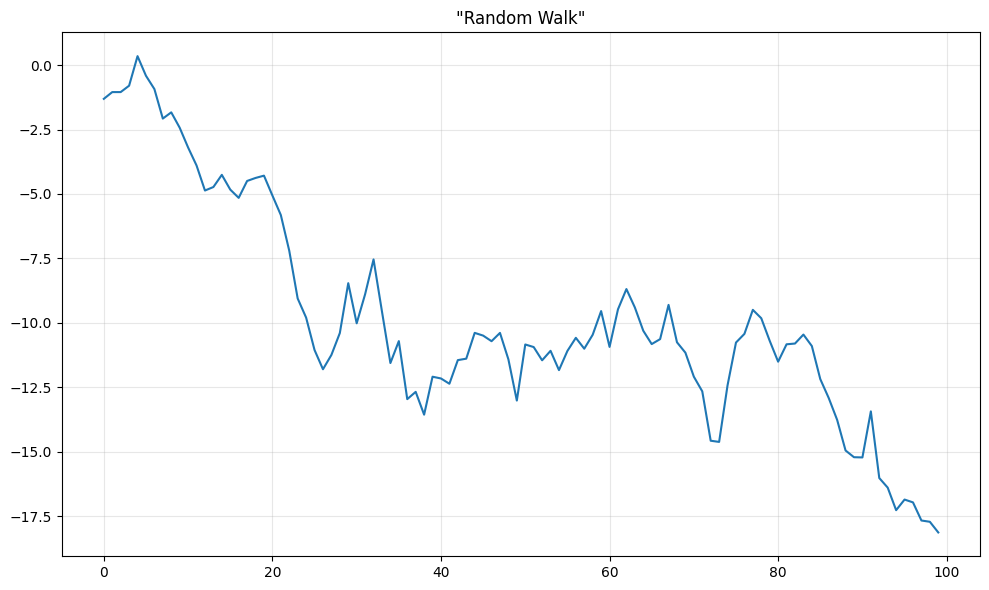

In [49]:
sample_data = np.random.randn(100).cumsum()
%quickplot sample_data -t line --title "Random Walk"

## Часть 3. Расширенные техники

### 3.1. Создание IPython extension модуля

In [55]:
# Создаём модуль расширения
extension_code = '''
"""
Custom IPython Extension for Colab
"""
from IPython.core.magic import register_line_magic, register_cell_magic
from IPython.core.magic_arguments import argument, magic_arguments, parse_argstring

@magic_arguments()
@argument('message', nargs='*', default=['Ready!'], help='Сообщение')
@register_line_magic
def status(line):
    """Показать статус выполнения"""
    args = parse_argstring(status, line)
    # Объединяем все аргументы в одну строку
    message = ' '.join(args.message)
    print(f"✅ Status: {message}")
    return message

@register_cell_magic
def repeat(line, cell):
    """Повторить выполнение ячейки N раз"""
    try:
        n = int(line.strip()) if line.strip() else 2
    except ValueError:
        print("❌ Please provide a valid number")
        return

    for i in range(n):
        print(f"\\n--- Iteration {i+1}/{n} ---")
        # Исправляем: user_global_scope -> user_global_ns
        exec(cell, get_ipython().user_global_ns)

def load_ipython_extension(ipython):
    """Функция загрузки расширения"""
    # Магические команды регистрируются автоматически через декораторы
    print("🔌 Custom Colab extension loaded!")

def unload_ipython_extension(ipython):
    """Функция выгрузки расширения"""
    print("🔌 Custom Colab extension unloaded!")
'''

# Сохраняем как модуль
with open('/content/colab_extensions.py', 'w') as f:
    f.write(extension_code)

print("✅ Extension module created: /content/colab_extensions.py")

✅ Extension module created: /content/colab_extensions.py


### 3.2. Загрузка расширения

In [57]:
# Загружаем наше расширение
# %load_ext colab_extensions
%reload_ext colab_extensions

# Теперь можем использовать новые команды:
%status All systems operational

🔌 Custom Colab extension unloaded!
🔌 Custom Colab extension loaded!
✅ Status: All systems operational


'All systems operational'

In [60]:
%status

✅ Status: Ready!


'Ready!'

In [58]:
%%repeat 3
import random
print(f"Random number: {random.randint(1, 100)}")


--- Iteration 1/3 ---
Random number: 62

--- Iteration 2/3 ---
Random number: 3

--- Iteration 3/3 ---
Random number: 43


### 3.3. Extension с конфигурацией

In [61]:
class ExtensionConfig:
    """Конфигурация расширения"""
    def __init__(self):
        self.verbose = True
        self.cache_enabled = True
        self.max_retries = 3

    def __repr__(self):
        return f"ExtensionConfig(verbose={self.verbose}, cache={self.cache_enabled})"

# Глобальный конфиг
ext_config = ExtensionConfig()

@register_line_magic
def extconfig(line):
    """
    Управление конфигурацией расширений.

    Usage:
        %extconfig show
        %extconfig set verbose=True
    """
    global ext_config

    parts = line.strip().split()
    if not parts:
        print(ext_config)
        return

    command = parts[0]

    if command == 'show':
        print(ext_config)
    elif command == 'set':
        if len(parts) > 1:
            key, value = parts[1].split('=')
            if hasattr(ext_config, key):
                setattr(ext_config, key, eval(value))
                print(f"✅ Set {key} = {value}")
            else:
                print(f"❌ Unknown config key: {key}")
    else:
        print("Usage: %extconfig [show|set key=value]")

In [62]:
%extconfig show
%extconfig set verbose=False
%extconfig show

ExtensionConfig(verbose=True, cache=True)
✅ Set verbose = False
ExtensionConfig(verbose=False, cache=True)


# Часть 4. ipywidgets

## 4.1. About
`ipywidgets` - это библиотека для создания интерактивных элементов управления в Jupyter/Colab. Она позволяет превратить статические ноутбуки в интерактивные приложения с обратной связью.

## 4.2. Интерактивная настройка параметров модели

In [76]:
import ipywidgets as widgets
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

# Создаём ползунки для параметров
slider_amplitude = widgets.FloatSlider(value=1, min=0, max=10, step=0.1, description='Амплитуда:')
slider_frequency = widgets.FloatSlider(value=1, min=0.1, max=5, step=0.1, description='Частота:')
slider_phase = widgets.FloatSlider(value=0, min=0, max=2*np.pi, step=0.1, description='Фаза:')

# Функция обновления графика
def update_plot(amplitude, frequency, phase):
    x = np.linspace(0, 2*np.pi, 100)
    y = amplitude * np.sin(frequency * x + phase)

    plt.figure(figsize=(8, 4))
    plt.plot(x, y)
    plt.grid(True)
    plt.ylim(-10, 10)
    plt.title(f'Sin({frequency}x + {phase:.2f})')
    plt.show()

# Связываем ползунки с функцией
interactive_plot = widgets.interactive(update_plot,
                                       amplitude=slider_amplitude,
                                       frequency=slider_frequency,
                                       phase=slider_phase)

display(interactive_plot)

interactive(children=(FloatSlider(value=1.0, description='Амплитуда:', max=10.0), FloatSlider(value=1.0, descr…

## 4.3 Визуальный конструктор запросов

In [71]:
import ipywidgets as widgets
from IPython.display import display

# Создаём различные элементы ввода
name_input = widgets.Text(description='Имя:', placeholder='Введите имя')
age_input = widgets.IntText(description='Возраст:', value=18)
gender_radio = widgets.RadioButtons(
    options=['Мужской', 'Женский'],
    description='Пол:'
)
hobby_checkbox = widgets.SelectMultiple(
    options=['Спорт', 'Музыка', 'Книги', 'Кино', 'Программирование'],
    description='Хобби:'
)
submit_button = widgets.Button(description='Отправить', button_style='success')
result_output = widgets.Output()

def on_submit(b):
    with result_output:
        result_output.clear_output()
        print("📋 Анкета заполнена:")
        print(f"  Имя: {name_input.value or 'не указано'}")
        print(f"  Возраст: {age_input.value}")
        print(f"  Пол: {gender_radio.value}")
        print(f"  Хобби: {', '.join(hobby_checkbox.value) if hobby_checkbox.value else 'не указаны'}")

        # Проверка условий
        if age_input.value >= 18:
            print("✅ Совершеннолетний")
        else:
            print("⚠️ Несовершеннолетний")

submit_button.on_click(on_submit)

# Группируем виджеты
box = widgets.VBox([name_input, age_input, gender_radio, hobby_checkbox, submit_button, result_output])
display(box)

## 4.4 Интерактивное тестирование

In [72]:
import ipywidgets as widgets
from IPython.display import display
import random

# Вопросы и ответы
questions = {
    'Python - это...': 'Язык программирования',
    'Что такое Jupyter?': 'Интерактивная среда',
    'NumPy используется для...': 'Работы с массивами'
}

# Создаём интерфейс теста
current_question = 0
score = 0

question_label = widgets.Label(value=list(questions.keys())[0])
answer_input = widgets.Text(description='Ваш ответ:', placeholder='Введите ответ...')
check_button = widgets.Button(description='Проверить', button_style='primary')
next_button = widgets.Button(description='Следующий вопрос', button_style='success', disabled=True)
result_label = widgets.Label(value='')
score_label = widgets.Label(value='Баллы: 0')

def check_answer(b):
    global score
    user_answer = answer_input.value.strip()
    correct_answer = questions[question_label.value]

    if user_answer.lower() == correct_answer.lower():
        result_label.value = "✅ Правильно!"
        score += 1
        check_button.disabled = True
        next_button.disabled = False
    else:
        result_label.value = f"❌ Неправильно! Правильный ответ: {correct_answer}"
        check_button.disabled = True
        next_button.disabled = False

    score_label.value = f"Баллы: {score}/{len(questions)}"

def next_question(b):
    global current_question
    current_question += 1

    if current_question < len(questions):
        question_label.value = list(questions.keys())[current_question]
        answer_input.value = ''
        result_label.value = ''
        check_button.disabled = False
        next_button.disabled = True
    else:
        result_label.value = f"🎉 Тест завершён! Итоговый счёт: {score}/{len(questions)}"
        next_button.disabled = True
        check_button.disabled = True

check_button.on_click(check_answer)
next_button.on_click(next_question)

ui = widgets.VBox([question_label, answer_input, check_button, next_button, result_label, score_label])
display(ui)

# Заключение

### Ключевые моменты:

1. **Magic-команды** — простой способ создать расширение
2. **Декораторы** `@register_line_magic`, `@register_cell_magic` упрощают регистрацию
3. **@magic_arguments** позволяет парсить аргументы как в CLI
4. **IPython extensions** — модульный подход для сложных расширений
5. **В Colab** расширения создаются в рантайме и сохраняются в `/content`

### Дополнительные материалы:

- [IPython Magic Documentation](https://ipython.readthedocs.io/en/stable/config/magics.html)
- [Creating IPython Extensions](https://ipython.readthedocs.io/en/stable/config/extensions/index.html)
- [Jupyter Notebook Extensions](https://github.com/ipython-contrib/jupyter_contrib_nbextensions)
